      Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679
Optimal EPS = 0.0536


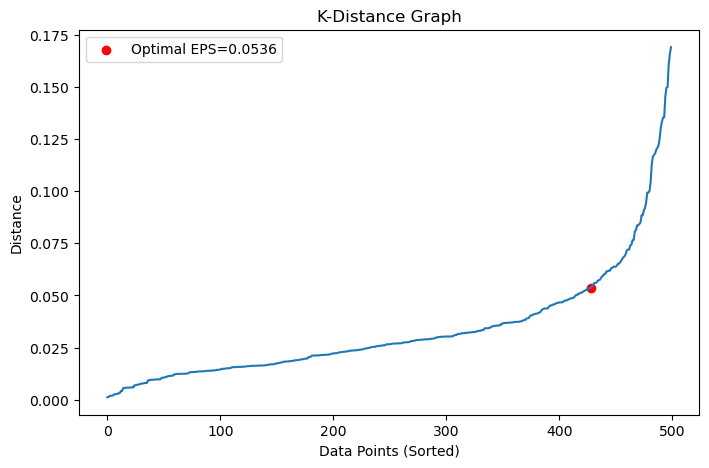

        Weight      Height  clusters
0    67.062924  176.086355         0
1    68.804094  178.388669        -1
2    60.930863  170.284496         1
3    59.733843  168.691992         2
4    65.431230  173.763679        -1
..         ...         ...       ...
495  59.976983  169.679741         1
496  66.423814  174.625574        26
497  53.604698  161.919208         5
498  50.433644  160.794875        -1
499  60.224392  169.689709         1

[500 rows x 3 columns]
total_cluster  50
total_noise  72


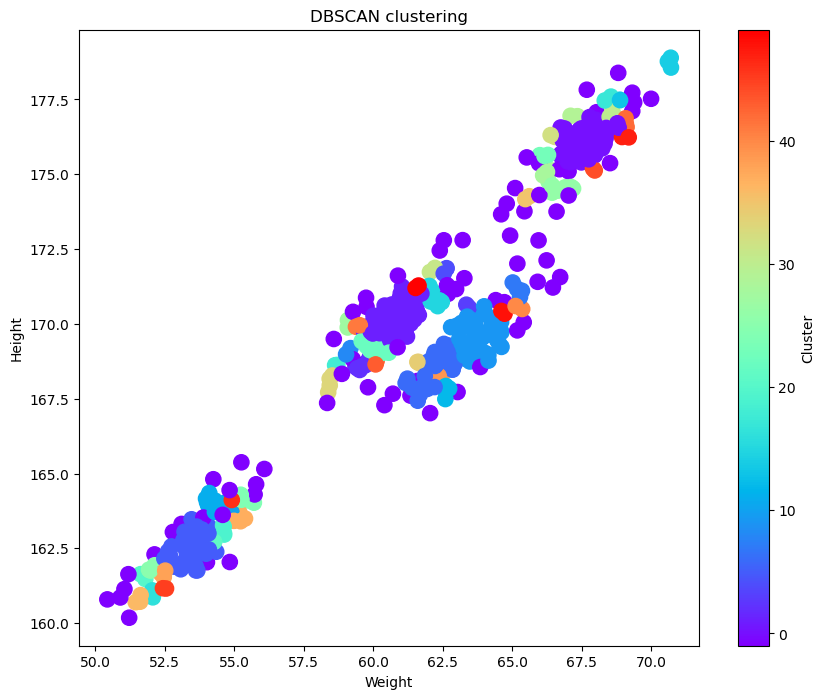

NameError: name 'pickle' is not defined

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv(r"D:\Python-Course\ML-Course\test\Kaggle\Clustering_gmm_dbscan.csv")
print(df.head())
X = df[['Weight', 'Height']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# print(x_scaled)
min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, min_samples - 1])
n_points = len(distances)
all_points = np.vstack((np.arange(n_points), distances)).T
first_point = all_points[0]
last_point = all_points[-1]
line_vec = last_point - first_point
line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
vec_from_first = all_points - first_point
scalar_product = np.sum(vec_from_first * line_vec_norm,axis=1)
vec_to_line = (vec_from_first - np.outer(scalar_product, line_vec_norm))
dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
elbow_idx = np.argmax(dist_to_line)
best_eps = distances[elbow_idx]
print(f"Optimal EPS = {best_eps:.4f}")

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.scatter(
    elbow_idx,
    best_eps,
    color='red',
    label=f'Optimal EPS={best_eps:.4f}'
)

plt.title("K-Distance Graph")
plt.xlabel("Data Points (Sorted)")
plt.ylabel("Distance")
plt.legend()
plt.show()
dbscan_model = DBSCAN(eps = best_eps, min_samples = min_samples)
cluster = dbscan_model.fit_predict(X_scaled)
df['clusters'] =  cluster
print(df)
total_cluster = len(set(cluster)) - (1 if -1 in cluster else 0)
total_noise = list(cluster).count(-1)
print('total_cluster ',total_cluster)
print('total_noise ',total_noise)

plt.figure(figsize=(10,8))
plt.scatter(
            df['Weight'],
            df['Height'],
            c = df['clusters'],    
            cmap="rainbow",
            s =120
        )
plt.title('DBSCAN clustering')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.colorbar(label="Cluster")
# plt.grid(True)
plt.show()

with open(r"D:\Python-Course\ML-Course\test\Machine-Learning-Algorithm\DBSCAN-Algorithm\dbscan_model.pkl",'wb') as f: 
    pickle.dump(dbscan_model, f)